In [12]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [13]:
data = {
    "Outlook": ["Sunny","Sunny","Overcast","Rain","Rain","Rain",
                "Overcast","Sunny","Sunny","Rain","Sunny",
                "Overcast","Overcast","Rain"],

    "Temperature": ["Hot","Hot","Hot","Mild","Cool","Cool",
                    "Cool","Mild","Cool","Mild","Mild",
                    "Mild","Hot","Mild"],

    "Humidity": ["High","High","High","High","Normal","Normal",
                 "Normal","High","Normal","Normal","Normal",
                 "High","Normal","High"],

    "Wind": ["Weak","Strong","Weak","Weak","Weak","Strong",
             "Strong","Weak","Weak","Weak","Strong",
             "Strong","Weak","Strong"],

    "Play": ["No","No","Yes","Yes","Yes","No",
             "Yes","No","Yes","Yes","Yes",
             "Yes","Yes","No"]
}

df = pd.DataFrame(data)

In [14]:
df

,Outlook,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [15]:
encoder = LabelEncoder()

for col in df.columns:
    df[col] = encoder.fit_transform(df[col])

In [16]:
X = df.drop("Play", axis=1)
y = df["Play"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#Where: test_size=0.2 → 20% data for testing
# random_state=42 → Ensures the same split every time you run the code
# X_train → Training features
# X_test → Testing features
# y_train → Training labels
# y_test → Testing labels

In [18]:
model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)    

In [19]:
model.fit(X, y)


DecisionTreeClassifier(criterion='entropy', random_state=42)

In [20]:
prediction = model.predict(X)

print("Accuracy:", accuracy_score(y, prediction))

Accuracy: 1.0


In [21]:
# Outlook = Sunny
# Temperature = Cool
# Humidity = High
# Wind = Weak

sample = [[2,0,0,1]]

prediction = model.predict(sample)

print(prediction)

[0]


c:\Users\Amritanshu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


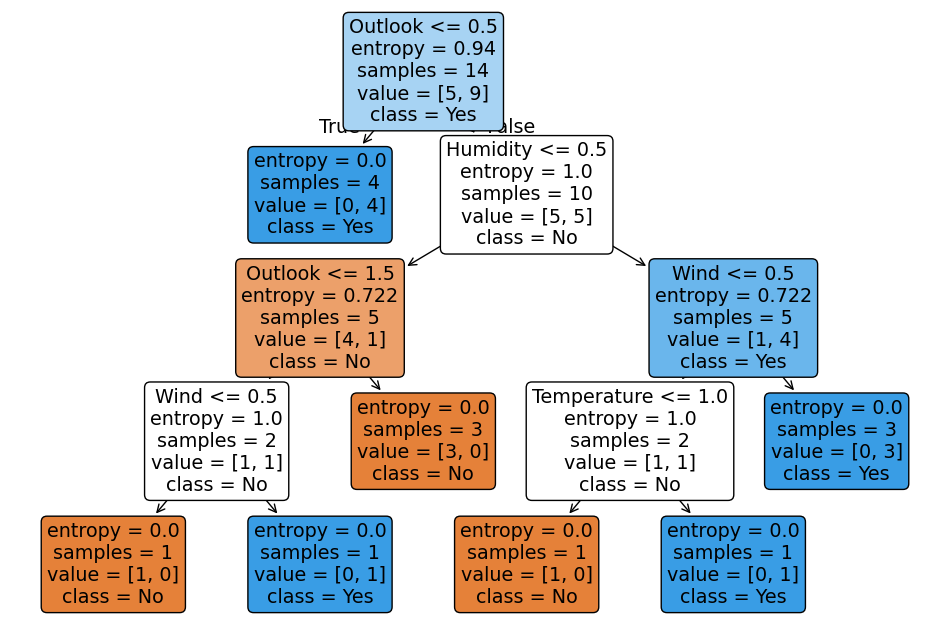

In [22]:

plt.figure(figsize=(12,8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No","Yes"],
    filled=True,
    rounded=True
)

plt.show()